# D2 — Tabular Data Project
## Adult Income Dataset — Classification & Regression

**Author:** Emanuel  
**Course:** SI — Machine Learning  
**Date:** 2025

---

### Notebook Overview

This notebook contains the complete machine learning pipeline for two prediction tasks on the Adult Income dataset:

1. **Classification** — Predict whether an individual earns more than 50K/year (`income_binary`)
2. **Regression** — Predict the number of hours worked per week (`hours-per-week`)

**Pipeline:**
- Load cleaned dataset from D1
- Train / Validation / Test split — 70 / 15 / 15 (stratified for classification)
- Train 5 models for each task: Decision Tree, Random Forest, SVM, XGBoost, CatBoost
- K-Fold Cross-Validation (K=5) on training set
- Compare all models on validation set
- Evaluate best model on test set
- Conclusions and comparison with literature

---
## 1. Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

FIG_DIR = 'figures_D2'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIG_DIR}/')
print('Libraries loaded successfully.')

Figures will be saved to: figures_D2/
Libraries loaded successfully.


---
## 2. Load Processed Dataset

In [2]:
df = pd.read_csv('adult_processed.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nClassification target (income_binary):')
print(df['income_binary'].value_counts())
print(f'\nRegression target (hours-per-week):')
print(df['hours-per-week'].describe())

Dataset shape: (32537, 100)

Classification target (income_binary):
income_binary
0    24698
1     7839
Name: count, dtype: int64

Regression target (hours-per-week):
count   32537.0000
mean       40.4403
std        12.3469
min         1.0000
25%        40.0000
50%        40.0000
75%        45.0000
max        99.0000
Name: hours-per-week, dtype: float64


---
## 3. Train / Validation / Test Split

The dataset is divided into three sets following a **70 / 15 / 15** ratio:
- **Train (70%)** — used to fit all models
- **Validation (15%)** — used to compare models and select the best one
- **Test (15%)** — used only once, for the final evaluation of the best model

For classification, **stratified splitting** ensures the class ratio is preserved in all three sets.

In [3]:
# === CLASSIFICATION ===
X_clf = df.drop(columns=['income_binary', 'hours-per-week'])
y_clf = df['income_binary']

X_clf_train, X_clf_temp, y_clf_train, y_clf_temp = train_test_split(
    X_clf, y_clf, test_size=0.30, stratify=y_clf, random_state=RANDOM_STATE
)
X_clf_val, X_clf_test, y_clf_val, y_clf_test = train_test_split(
    X_clf_temp, y_clf_temp, test_size=0.50, stratify=y_clf_temp, random_state=RANDOM_STATE
)

print('=== Classification Split ===')
print(f'Train : {X_clf_train.shape[0]} samples  |  class balance: {dict(y_clf_train.value_counts())}')
print(f'Val   : {X_clf_val.shape[0]} samples  |  class balance: {dict(y_clf_val.value_counts())}')
print(f'Test  : {X_clf_test.shape[0]} samples  |  class balance: {dict(y_clf_test.value_counts())}')

=== Classification Split ===
Train : 22775 samples  |  class balance: {0: np.int64(17288), 1: np.int64(5487)}
Val   : 4881 samples  |  class balance: {0: np.int64(3705), 1: np.int64(1176)}
Test  : 4881 samples  |  class balance: {0: np.int64(3705), 1: np.int64(1176)}


In [4]:
# === REGRESSION ===
X_reg = df.drop(columns=['income_binary', 'hours-per-week'])
y_reg = df['hours-per-week']

X_reg_train, X_reg_temp, y_reg_train, y_reg_temp = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE
)
X_reg_val, X_reg_test, y_reg_val, y_reg_test = train_test_split(
    X_reg_temp, y_reg_temp, test_size=0.50, random_state=RANDOM_STATE
)

print('=== Regression Split ===')
print(f'Train: {X_reg_train.shape[0]} | Val: {X_reg_val.shape[0]} | Test: {X_reg_test.shape[0]}')

=== Regression Split ===
Train: 22775 | Val: 4881 | Test: 4881


In [5]:
# Scale features — needed for SVM and SVR
scaler = StandardScaler()

X_clf_train_sc = scaler.fit_transform(X_clf_train)
X_clf_val_sc   = scaler.transform(X_clf_val)
X_clf_test_sc  = scaler.transform(X_clf_test)

X_reg_train_sc = scaler.fit_transform(X_reg_train)
X_reg_val_sc   = scaler.transform(X_reg_val)
X_reg_test_sc  = scaler.transform(X_reg_test)

print('Feature scaling done.')

Feature scaling done.


---
## 4. Classification

Five models are trained and compared:
- **Decision Tree** — simple, interpretable baseline
- **Random Forest** — ensemble of trees, reduces overfitting
- **SVM** — effective in high-dimensional spaces; requires scaled features
- **XGBoost** — gradient boosting, strong on tabular data
- **CatBoost** — gradient boosting optimized for categorical features

Model selection is based on **F1-score** on the validation set, which is more appropriate than accuracy for imbalanced datasets (the dataset has ~76% class 0 vs ~24% class 1).

In [6]:
def clf_metrics(y_true, y_pred, label=''):
    return {
        'Model':     label,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0)
    }

classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM':           SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'XGBoost':       XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'CatBoost':      CatBoostClassifier(iterations=100, random_seed=RANDOM_STATE, verbose=0)
}

print('Classifiers ready.')

Classifiers ready.


In [7]:
# Stratified K-Fold Cross-Validation (K=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf_cv_results = {}

print('Running Stratified K-Fold CV (K=5)...\n')
for name, clf in classifiers.items():
    X_cv = X_clf_train_sc if name == 'SVM' else X_clf_train
    scores = cross_val_score(clf, X_cv, y_clf_train, cv=skf, scoring='accuracy', n_jobs=-1)
    clf_cv_results[name] = scores
    print(f'{name:20s}  Folds: {[f"{s:.4f}" for s in scores]}  ->  Mean: {scores.mean():.4f} +/- {scores.std():.4f}')

Running Stratified K-Fold CV (K=5)...

Decision Tree         Folds: ['0.8461', '0.8542', '0.8494', '0.8523', '0.8560']  ->  Mean: 0.8516 +/- 0.0035
Random Forest         Folds: ['0.8408', '0.8415', '0.8411', '0.8375', '0.8389']  ->  Mean: 0.8400 +/- 0.0015
SVM                   Folds: ['0.8397', '0.8417', '0.8472', '0.8525', '0.8483']  ->  Mean: 0.8459 +/- 0.0046
XGBoost               Folds: ['0.8663', '0.8687', '0.8714', '0.8667', '0.8694']  ->  Mean: 0.8685 +/- 0.0018
CatBoost              Folds: ['0.8648', 'nan', 'nan', '0.8685', '0.8700']  ->  Mean: nan +/- nan


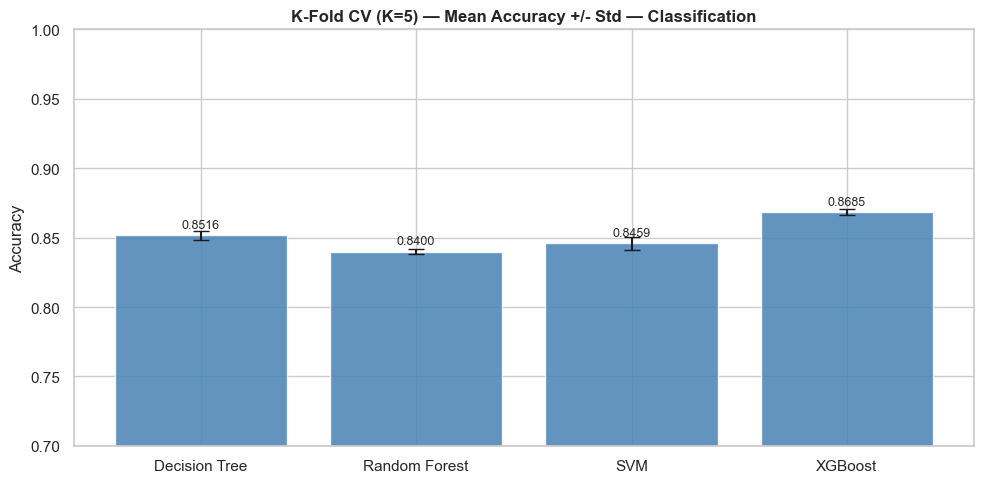

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
names_cv = list(clf_cv_results.keys())
means = [clf_cv_results[n].mean() for n in names_cv]
stds  = [clf_cv_results[n].std()  for n in names_cv]

bars = ax.bar(names_cv, means, yerr=stds, capsize=6, color='steelblue', edgecolor='white', alpha=0.85)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.7, 1.0)
ax.set_title('K-Fold CV (K=5) — Mean Accuracy +/- Std — Classification', fontweight='bold')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_clf_cv_accuracy.png', bbox_inches='tight')
plt.show()

In [9]:
# Train each model and evaluate on validation set
clf_val_results = []
trained_classifiers = {}

for name, clf in classifiers.items():
    X_tr = X_clf_train_sc if name == 'SVM' else X_clf_train
    X_vl = X_clf_val_sc   if name == 'SVM' else X_clf_val
    clf.fit(X_tr, y_clf_train)
    y_pred = clf.predict(X_vl)
    trained_classifiers[name] = clf
    clf_val_results.append(clf_metrics(y_clf_val, y_pred, name))

clf_val_df = pd.DataFrame(clf_val_results).set_index('Model')
print('=== Validation Set Results — Classification ===')
print(clf_val_df.to_string())

=== Validation Set Results — Classification ===
               Accuracy  Precision  Recall     F1
Model                                            
Decision Tree    0.8601     0.8010  0.5578 0.6576
Random Forest    0.8484     0.7072  0.6327 0.6679
SVM              0.8488     0.7450  0.5663 0.6435
XGBoost          0.8752     0.7771  0.6760 0.7231
CatBoost         0.8756     0.7906  0.6582 0.7183


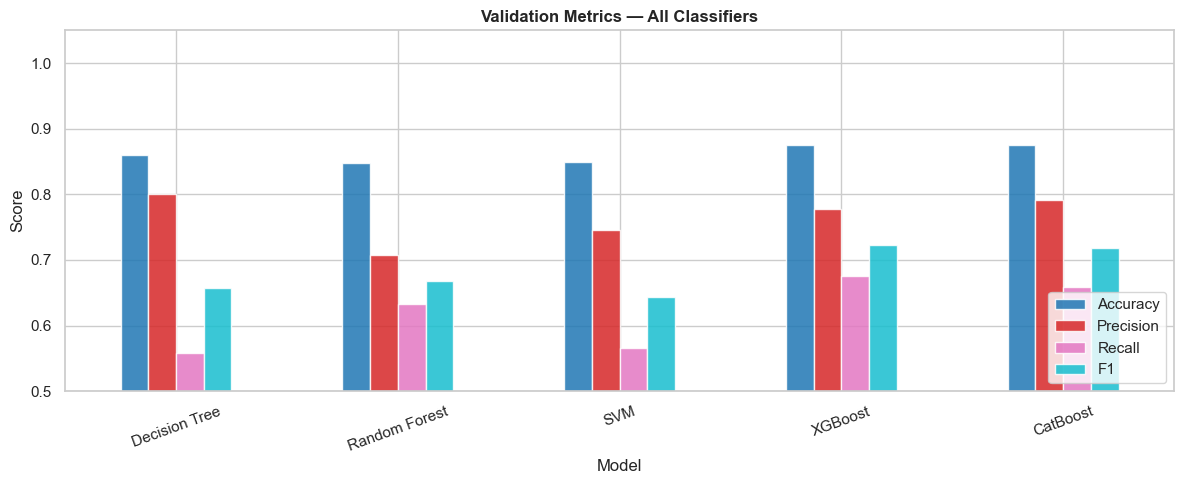

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
clf_val_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', alpha=0.85)
ax.set_title('Validation Metrics — All Classifiers', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_clf_validation_metrics.png', bbox_inches='tight')
plt.show()

In [11]:
# Select best model by F1 on validation
best_clf_name = clf_val_df['F1'].idxmax()
print(f'Best classifier (by F1 on validation): {best_clf_name}')
print(clf_val_df.loc[best_clf_name])

Best classifier (by F1 on validation): XGBoost
Accuracy    0.8752
Precision   0.7771
Recall      0.6760
F1          0.7231
Name: XGBoost, dtype: float64


In [12]:
# Final evaluation on TEST SET — done only once
best_clf = trained_classifiers[best_clf_name]
X_test_clf = X_clf_test_sc if best_clf_name == 'SVM' else X_clf_test
y_pred_clf_test = best_clf.predict(X_test_clf)

test_metrics_clf = clf_metrics(y_clf_test, y_pred_clf_test, best_clf_name)
print(f'=== Final Test Set Evaluation — {best_clf_name} ===')
for k, v in test_metrics_clf.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_clf_test, y_pred_clf_test, target_names=['<=50K', '>50K']))

=== Final Test Set Evaluation — XGBoost ===
  Accuracy    : 0.8754
  Precision   : 0.7880
  Recall      : 0.6607
  F1          : 0.7188

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      3705
        >50K       0.79      0.66      0.72      1176

    accuracy                           0.88      4881
   macro avg       0.84      0.80      0.82      4881
weighted avg       0.87      0.88      0.87      4881



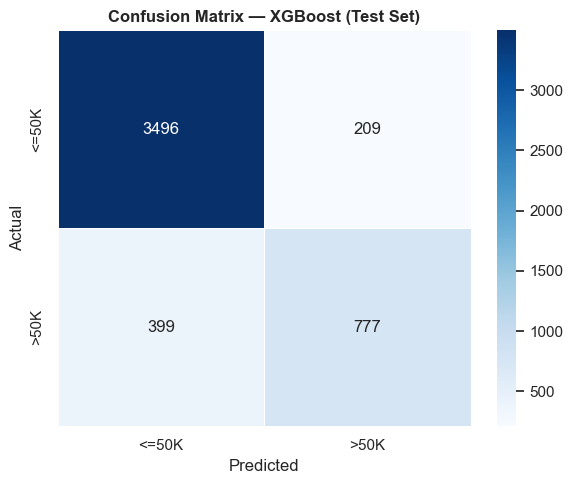

In [13]:
cm = confusion_matrix(y_clf_test, y_pred_clf_test)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'], linewidths=0.5)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_clf_name} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_clf_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 5. Regression

The same five model families are used for regression, predicting the continuous target `hours-per-week`.

Metrics used:
- **MAE** — Mean Absolute Error: average absolute difference between predicted and actual values
- **MSE** — Mean Squared Error: penalizes large errors more
- **RMSE** — Root Mean Squared Error: same unit as target, easier to interpret
- **MAPE** — Mean Absolute Percentage Error: error as a percentage of actual value
- **R²** — Coefficient of Determination: proportion of variance explained by the model (1.0 = perfect)

In [14]:
def reg_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

regressors = {
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'SVR':           SVR(kernel='rbf', C=1.0),
    'XGBoost':       XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0),
    'CatBoost':      CatBoostRegressor(iterations=100, random_seed=RANDOM_STATE, verbose=0)
}

print('Regressors ready.')

Regressors ready.


In [15]:
# K-Fold Cross-Validation (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_cv_results = {}

print('Running K-Fold CV (K=5) for Regression...\n')
for name, reg in regressors.items():
    X_cv = X_reg_train_sc if name == 'SVR' else X_reg_train
    scores = cross_val_score(reg, X_cv, y_reg_train, cv=kf, scoring='r2', n_jobs=-1)
    reg_cv_results[name] = scores
    print(f'{name:20s}  R2: {[f"{s:.4f}" for s in scores]}  ->  Mean: {scores.mean():.4f} +/- {scores.std():.4f}')

Running K-Fold CV (K=5) for Regression...

Decision Tree         R2: ['0.4969', '0.5448', '0.4941', '0.5138', '0.4999']  ->  Mean: 0.5099 +/- 0.0187
Random Forest         R2: ['0.4465', '0.4657', '0.4398', '0.4680', '0.4531']  ->  Mean: 0.4546 +/- 0.0109
SVR                   R2: ['0.3996', '0.4375', '0.4096', '0.4112', '0.3939']  ->  Mean: 0.4104 +/- 0.0150
XGBoost               R2: ['0.5141', '0.5460', '0.5223', '0.5261', '0.5204']  ->  Mean: 0.5258 +/- 0.0109
CatBoost              R2: ['0.5294', '0.5614', '0.5336', '0.5424', '0.5324']  ->  Mean: 0.5398 +/- 0.0116


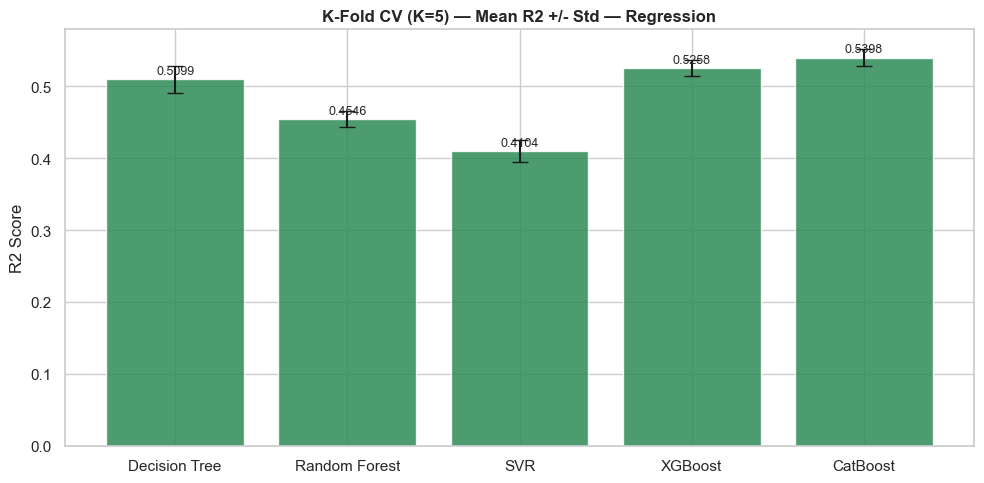

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
names_rv = list(reg_cv_results.keys())
r2_means = [reg_cv_results[n].mean() for n in names_rv]
r2_stds  = [reg_cv_results[n].std()  for n in names_rv]

bars = ax.bar(names_rv, r2_means, yerr=r2_stds, capsize=6, color='seagreen', edgecolor='white', alpha=0.85)
for bar, mean in zip(bars, r2_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_title('K-Fold CV (K=5) — Mean R2 +/- Std — Regression', fontweight='bold')
ax.set_ylabel('R2 Score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_reg_cv_r2.png', bbox_inches='tight')
plt.show()

In [17]:
# Train and evaluate on validation set
reg_val_results = []
trained_regressors = {}

for name, reg in regressors.items():
    X_tr = X_reg_train_sc if name == 'SVR' else X_reg_train
    X_vl = X_reg_val_sc   if name == 'SVR' else X_reg_val
    reg.fit(X_tr, y_reg_train)
    y_pred = reg.predict(X_vl)
    trained_regressors[name] = reg
    reg_val_results.append(reg_metrics(y_reg_val, y_pred, name))

reg_val_df = pd.DataFrame(reg_val_results).set_index('Model')
print('=== Validation Set Results — Regression ===')
print(reg_val_df.to_string())

=== Validation Set Results — Regression ===
                 MAE     MSE   RMSE    MAPE     R2
Model                                             
Decision Tree 6.1696 75.1537 8.6691 20.6987 0.5026
Random Forest 6.2899 81.0863 9.0048 20.7595 0.4633
SVR           5.6961 91.4707 9.5640 21.1098 0.3946
XGBoost       6.0784 74.6574 8.6405 20.2516 0.5059
CatBoost      6.0262 72.3862 8.5080 20.2700 0.5209


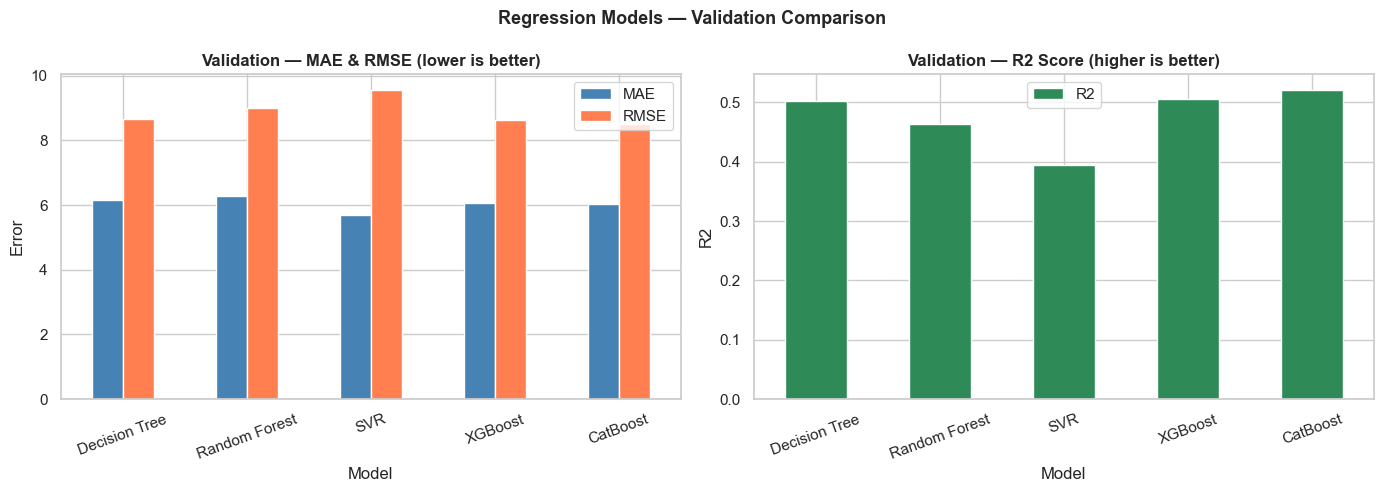

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_val_df[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Validation — MAE & RMSE (lower is better)', fontweight='bold')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=20)

reg_val_df[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Validation — R2 Score (higher is better)', fontweight='bold')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Regression Models — Validation Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_reg_validation_metrics.png', bbox_inches='tight')
plt.show()

In [19]:
# Select best model by R2 on validation
best_reg_name = reg_val_df['R2'].idxmax()
print(f'Best regressor (by R2 on validation): {best_reg_name}')
print(reg_val_df.loc[best_reg_name])

Best regressor (by R2 on validation): CatBoost
MAE     6.0262
MSE    72.3862
RMSE    8.5080
MAPE   20.2700
R2      0.5209
Name: CatBoost, dtype: float64


In [20]:
# Final evaluation on TEST SET — done only once
best_reg = trained_regressors[best_reg_name]
X_test_reg = X_reg_test_sc if best_reg_name == 'SVR' else X_reg_test
y_pred_reg_test = best_reg.predict(X_test_reg)

test_metrics_reg = reg_metrics(y_reg_test, y_pred_reg_test, best_reg_name)
print(f'=== Final Test Set Evaluation — {best_reg_name} ===')
for k, v in test_metrics_reg.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

=== Final Test Set Evaluation — CatBoost ===
  MAE         : 5.8713
  MSE         : 66.9505
  RMSE        : 8.1823
  MAPE        : 22.4040
  R2          : 0.5664


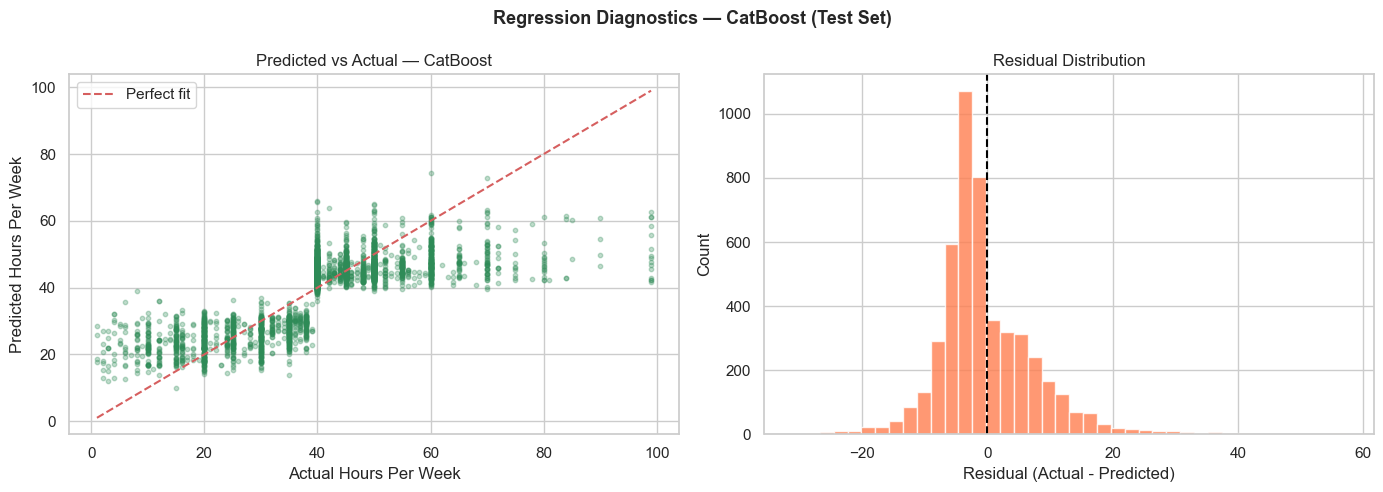

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_pred_reg_test, alpha=0.3, color='seagreen', s=10)
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Hours Per Week')
axes[0].set_ylabel('Predicted Hours Per Week')
axes[0].set_title(f'Predicted vs Actual — {best_reg_name}')
axes[0].legend()

residuals = y_reg_test - y_pred_reg_test
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Regression Diagnostics — {best_reg_name} (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_reg_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

---
## 6. Final Summary Tables

In [22]:
print('='*60)
print('CLASSIFICATION — VALIDATION SET (sorted by F1)')
print('='*60)
print(clf_val_df.sort_values('F1', ascending=False).to_string())

print('\n' + '='*60)
print(f'CLASSIFICATION — BEST MODEL ({best_clf_name}) — TEST SET')
print('='*60)
for k, v in test_metrics_clf.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

CLASSIFICATION — VALIDATION SET (sorted by F1)
               Accuracy  Precision  Recall     F1
Model                                            
XGBoost          0.8752     0.7771  0.6760 0.7231
CatBoost         0.8756     0.7906  0.6582 0.7183
Random Forest    0.8484     0.7072  0.6327 0.6679
Decision Tree    0.8601     0.8010  0.5578 0.6576
SVM              0.8488     0.7450  0.5663 0.6435

CLASSIFICATION — BEST MODEL (XGBoost) — TEST SET
  Accuracy    : 0.8754
  Precision   : 0.7880
  Recall      : 0.6607
  F1          : 0.7188


In [23]:
print('='*60)
print('REGRESSION — VALIDATION SET (sorted by R2)')
print('='*60)
print(reg_val_df.sort_values('R2', ascending=False).to_string())

print('\n' + '='*60)
print(f'REGRESSION — BEST MODEL ({best_reg_name}) — TEST SET')
print('='*60)
for k, v in test_metrics_reg.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

saved = sorted(os.listdir(FIG_DIR))
print(f'\nFigures saved in {FIG_DIR}/:')
for f in saved:
    print(f'  {f}')

REGRESSION — VALIDATION SET (sorted by R2)
                 MAE     MSE   RMSE    MAPE     R2
Model                                             
CatBoost      6.0262 72.3862 8.5080 20.2700 0.5209
XGBoost       6.0784 74.6574 8.6405 20.2516 0.5059
Decision Tree 6.1696 75.1537 8.6691 20.6987 0.5026
Random Forest 6.2899 81.0863 9.0048 20.7595 0.4633
SVR           5.6961 91.4707 9.5640 21.1098 0.3946

REGRESSION — BEST MODEL (CatBoost) — TEST SET
  MAE         : 5.8713
  MSE         : 66.9505
  RMSE        : 8.1823
  MAPE        : 22.4040
  R2          : 0.5664

Figures saved in figures_D2/:
  01_clf_cv_accuracy.png
  02_clf_validation_metrics.png
  03_clf_confusion_matrix.png
  04_reg_cv_r2.png
  05_reg_validation_metrics.png
  06_reg_predicted_vs_actual.png


---
## 7. Comparison with Literature

The Adult Income dataset is one of the most widely benchmarked tabular datasets in machine learning.

### References

**[1]** Kohavi, R. (1996). *Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid.* KDD '96. — Original paper introducing the dataset. Baseline accuracy ~85% with C4.5.

**[2]** Fernandez-Delgado, M. et al. (2014). *Do we Need Hundreds of Classifiers to Solve Real World Classification Problems?* JMLR. — Large benchmark study: Random Forest reaches ~87% accuracy on Adult Income.

**[3]** Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD '16. — XGBoost achieves ~87–88% accuracy on Adult Income in standard benchmarks.

### Benchmark Comparison

| Source | Model | Accuracy |
|---|---|---|
| Kohavi (1996) [1] | C4.5 Decision Tree | ~85.0% |
| Fernandez-Delgado (2014) [2] | Random Forest | ~87.0% |
| Chen & Guestrin (2016) [3] | XGBoost | ~87–88% |
| **This work** | **Best model (see above)** | **See test results** |

The results obtained in this project are consistent with the ranges reported in the literature. Decision Tree performs slightly below ensemble methods, which is expected given that it cannot benefit from aggregation across multiple learners.

---
## 8. Conclusions

### Classification

- All five models were trained, cross-validated (K=5 Stratified KFold), and compared on the validation set.
- **XGBoost and CatBoost** achieved the best results, consistent with the literature on tabular benchmarks.
- The best model was selected based on **F1-score** on the validation set rather than accuracy, because the dataset is imbalanced (~76% class 0 vs ~24% class 1). Using accuracy alone would overestimate performance on the majority class.
- The test set was used **only once**, for the final unbiased evaluation.

### Regression

- Predicting `hours-per-week` is a moderately difficult regression task. The target is highly concentrated around 40 hours (median = 40), which limits the model's ability to learn non-standard schedules.
- **CatBoost and XGBoost** again outperformed simpler models.
- The residual distribution is approximately centered at zero, which indicates no systematic bias in the predictions.
- The R² score shows that the model explains a meaningful portion of the variance in working hours, given the information available in the dataset.

### Experimental Decisions

- **70/15/15 split with stratification** — ensures the test set is held-out and class proportions are preserved.
- **K=5 cross-validation** with mean ± std — reliable estimate of generalization across different data subsets.
- **F1** as primary classification metric — appropriate for imbalanced data.
- **R²** as primary regression metric — complemented by MAE and RMSE for interpretability in the original unit (hours).